In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader

In [2]:
!pip install datasets

In [4]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [5]:
print(dataset["train"][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

In [6]:
print(dataset["train"][0]["text"])
print(dataset["train"][0]["label"])

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, eve

In [7]:
if dataset["train"][0]["label"] == 1:
    print("Positive")
else:
    print("Negative")

Negative


In [8]:
from collections import Counter

In [9]:
counter = Counter()

for example in dataset["train"]:
    words = example["text"].lower().split()
    counter.update(words)

In [11]:
print(counter.most_common(20))

[('the', 322198), ('a', 159953), ('and', 158572), ('of', 144462), ('to', 133967), ('is', 104171), ('in', 90527), ('i', 70480), ('this', 69714), ('that', 66292), ('it', 65505), ('/><br', 50935), ('was', 47024), ('as', 45102), ('for', 42843), ('with', 42729), ('but', 39764), ('on', 31619), ('movie', 30887), ('his', 29059)]


In [12]:
vocab = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word, count in counter.most_common(10000):
    vocab[word] = len(vocab)

print("Vocabulary size:", len(vocab))

Vocabulary size: 10002


In [13]:
def encode_text(text):
    words = text.lower().split()

    return [
        vocab.get(word, vocab["<UNK>"])
        for word in words
    ]

In [14]:
text = "this movie was amazing"

encoded = encode_text(text)

print(encoded)

[10, 20, 14, 531]


In [15]:
MAX_LENGTH = 200

def preprocess_text(text):

    tokens = encode_text(text)

    tokens = tokens[:MAX_LENGTH]

    if len(tokens) < MAX_LENGTH:
        tokens += [vocab["<PAD>"]] * (
            MAX_LENGTH - len(tokens)
        )

    return tokens

In [16]:
class IMDBDataset(Dataset):

    def __init__(self, hf_dataset):
        self.data = hf_dataset

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):

        text = self.data[index]["text"]
        label = self.data[index]["label"]

        tokens = preprocess_text(text)

        return (
            torch.tensor(tokens, dtype=torch.long),
            torch.tensor(label, dtype=torch.float32)
        )

In [17]:
train_dataset = IMDBDataset(dataset["train"])
test_dataset = IMDBDataset(dataset["test"])

In [18]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [19]:
x, y = next(iter(train_loader))

print("Input shape:", x.shape)
print("Labels shape:", y.shape)

Input shape: torch.Size([64, 200])
Labels shape: torch.Size([64])


In [20]:
class RNNClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_dim,
            1
        )

    def forward(self, x):

        x = self.embedding(x)

        output, hidden = self.rnn(x)

        final_hidden = hidden[-1]

        output = self.fc(final_hidden)

        return output.squeeze(1)

In [23]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [24]:
rnn_model = RNNClassifier(
    vocab_size=len(vocab)
).to(device)

print(rnn_model)

RNNClassifier(
  (embedding): Embedding(10002, 128, padding_idx=0)
  (rnn): RNN(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [25]:
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    rnn_model.parameters(),
    lr=0.001
)

In [27]:
epochs = 3

rnn_train_losses = []

for epoch in range(epochs):

    rnn_model.train()

    total_loss = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = rnn_model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    rnn_train_losses.append(average_loss)

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {average_loss:.4f}"
    )

Epoch 1/3, Loss: 0.6969
Epoch 2/3, Loss: 0.6895
Epoch 3/3, Loss: 0.6951


In [29]:
def evaluate_model(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for inputs, labels in loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            probabilities = torch.sigmoid(outputs)

            predictions = (
                probabilities >= 0.5
            ).float()

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return 100 * correct / total

In [30]:
def evaluate_model(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for inputs, labels in loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)

            probabilities = torch.sigmoid(outputs)

            predictions = (
                probabilities >= 0.5
            ).float()

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return 100 * correct / total

In [31]:
rnn_accuracy = evaluate_model(
    rnn_model,
    test_loader
)

print(
    f"RNN Test Accuracy: "
    f"{rnn_accuracy:.2f}%"
)

RNN Test Accuracy: 51.16%


In [32]:
nn.LSTM

torch.nn.modules.rnn.LSTM

In [33]:
class LSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_dim,
            1
        )

    def forward(self, x):

        x = self.embedding(x)

        output, (hidden, cell) = self.lstm(x)

        final_hidden = hidden[-1]

        output = self.fc(final_hidden)

        return output.squeeze(1)

In [34]:
lstm_model = LSTMClassifier(
    vocab_size=len(vocab)
).to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    lstm_model.parameters(),
    lr=0.001
)

In [35]:
lstm_train_losses = []

for epoch in range(epochs):

    lstm_model.train()

    total_loss = 0

    for inputs, labels in train_loader:

        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = lstm_model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)

    lstm_train_losses.append(average_loss)

    print(
        f"Epoch {epoch+1}/{epochs}, "
        f"Loss: {average_loss:.4f}"
    )

Epoch 1/3, Loss: 0.6938
Epoch 2/3, Loss: 0.6917
Epoch 3/3, Loss: 0.6748


In [36]:
lstm_accuracy = evaluate_model(
    lstm_model,
    test_loader
)

print(
    f"LSTM Test Accuracy: "
    f"{lstm_accuracy:.2f}%"
)

LSTM Test Accuracy: 63.23%


In [37]:
steps = np.arange(1, 31)

gradient = 0.5 ** steps

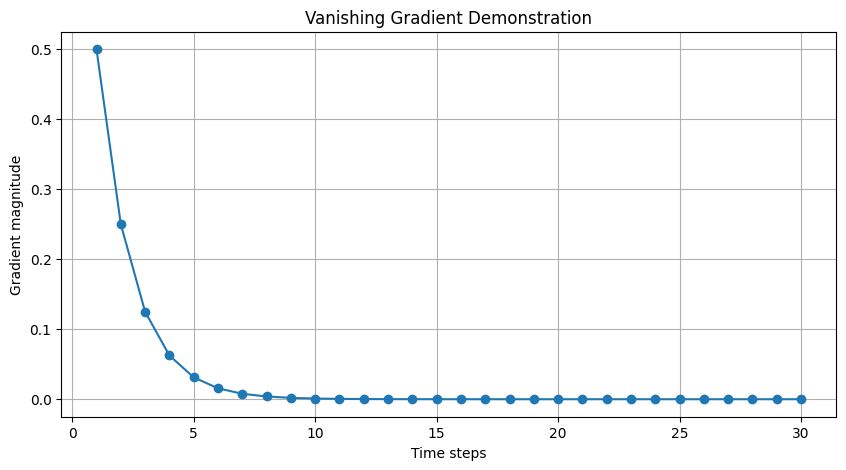

In [38]:
plt.figure(figsize=(10, 5))

plt.plot(
    steps,
    gradient,
    marker="o"
)

plt.xlabel("Time steps")
plt.ylabel("Gradient magnitude")
plt.title("Vanishing Gradient Demonstration")

plt.grid()

plt.show()

In [39]:
rnn_model.train()

inputs, labels = next(iter(train_loader))

inputs = inputs.to(device)
labels = labels.to(device)

rnn_model.zero_grad()

outputs = rnn_model(inputs)

loss = criterion(outputs, labels)

loss.backward()

In [40]:
for name, parameter in rnn_model.named_parameters():

    if parameter.grad is not None:

        print(
            name,
            parameter.grad.norm().item()
        )

embedding.weight 0.005065646953880787
rnn.weight_ih_l0 0.04516677185893059
rnn.weight_hh_l0 0.09258391708135605
rnn.bias_ih_l0 0.0066719939932227135
rnn.bias_hh_l0 0.006671993527561426
fc.weight 1.1466201543807983
fc.bias 0.07165731489658356


In [41]:
lstm_model.train()

inputs, labels = next(iter(train_loader))

inputs = inputs.to(device)
labels = labels.to(device)

lstm_model.zero_grad()

outputs = lstm_model(inputs)

loss = criterion(outputs, labels)

loss.backward()

In [42]:
for name, parameter in lstm_model.named_parameters():

    if parameter.grad is not None:

        print(
            name,
            parameter.grad.norm().item()
        )

embedding.weight 0.023905154317617416
lstm.weight_ih_l0 0.12957286834716797
lstm.weight_hh_l0 0.0780230313539505
lstm.bias_ih_l0 0.020319337025284767
lstm.bias_hh_l0 0.020319337025284767
fc.weight 0.08730977028608322
fc.bias 0.018421102315187454


conclusion :The experiment demonstrates the tendency of gradients to become very small across long recurrent sequences and shows why LSTM's memory mechanism was designed to better preserve information and gradient flow.

| Feature                | RNN              | LSTM      |
| ---------------------- | ---------------- | --------- |
| Sequential processing  | Yes              | Yes       |
| Hidden state           | Yes              | Yes       |
| Cell state             | No               | Yes       |
| Gates                  | No               | Yes       |
| Long-term dependencies | Difficult        | Better    |
| Vanishing gradient     | More susceptible | Mitigated |
| Complexity             | Lower            | Higher    |
| Memory mechanism       | Simple           | Gated     |
